In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries_clean.csv')

print(matches.shape)
print(deliveries.shape)

(1212, 23)
(288226, 30)


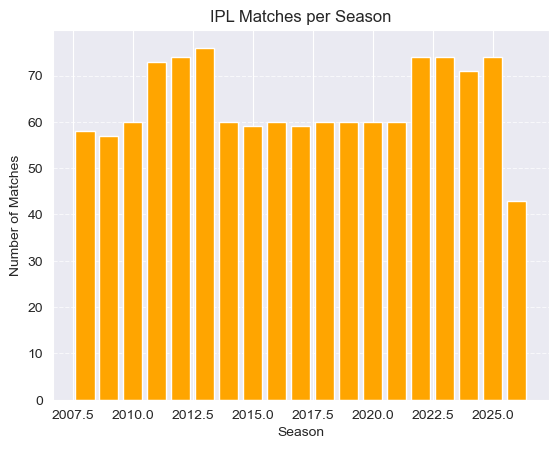

In [11]:
season_counts = matches['season'].value_counts().sort_index()

plt.bar(season_counts.index, season_counts.values, color="orange")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.title("IPL Matches per Season")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

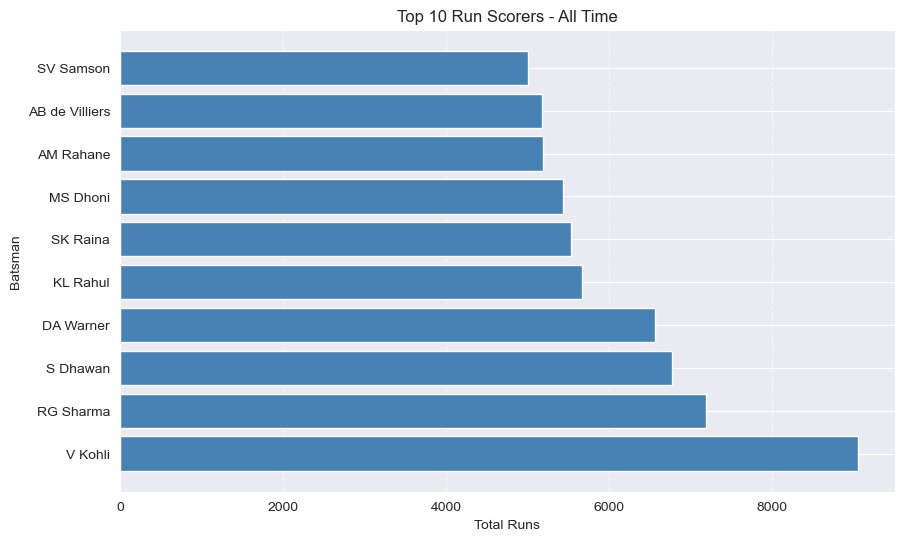

In [12]:
top_batsmen = deliveries.groupby('batter')['batter_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_batsmen.index, top_batsmen.values, color="steelblue")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.title("Top 10 Run Scorers - All Time")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
#groupby('batter')['batter_runs'].sum() — ye har batsman ka naam group karke uske saare runs jod deta hai (jaise Excel ka Pivot Table — 
#"batter" ke hisaab se group karo, "batter_runs" ka sum nikaalo).

#.sort_values(ascending=False) — sabse zyada runs wale batsman upar aa jaate hain.

#.head(10) — sirf top 10 rakhta hai, baaki hata deta hai.

#plt.barh() — horizontal bar chart (bar ki jagah barh — "h" matlab horizontal), player names lambe hote hain isliye horizontal better dikhta hai.

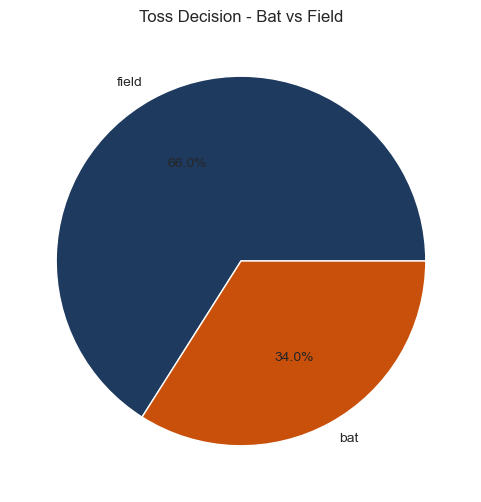

In [16]:
toss_counts = matches['toss_decision'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(toss_counts.values, labels=toss_counts.index, autopct='%1.1f%%', colors=['#1E3A5F','#C9500A'])
plt.title("Toss Decision - Bat vs Field")
plt.show()

In [ ]:
#value_counts() — pehle bhi use kiya tha, toss_decision column mein "bat" kitni baar aaya aur "field" kitni baar, uska count deta hai.

#plt.pie() — pie chart banata hai:

#toss_counts.values → numbers (kitni baar bat/field chuna)
#labels=toss_counts.index → labels ("bat", "field")
#autopct='%1.1f%%' → percentage dikhata hai chart pe (jaise "65.2%")
#colors=[...] → do colors diye hain do slices ke liye

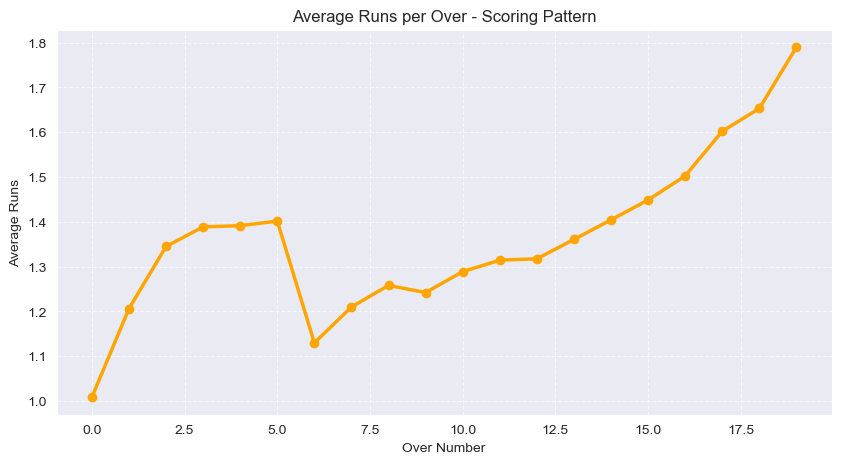

In [17]:
over_runs = deliveries.groupby('over_number')['total_runs'].mean()

plt.figure(figsize=(10,5))
plt.plot(over_runs.index, over_runs.values, color="orange", linewidth=2.5, marker='o')
plt.xlabel("Over Number")
plt.ylabel("Average Runs")
plt.title("Average Runs per Over - Scoring Pattern")
plt.grid(linestyle="--", alpha=0.7)
plt.show()

In [ ]:
#aya jo samajhna hai

groupby('over_number')['total_runs'].mean() — har over number
#(1, 2, 3...20) ke hisaab se group karke, us over mein average kitne runs bane wo nikal raha hai.

#plt.plot() — ye line chart banata hai (bar/barh/pie ki jagah plot) —
#trend/pattern dikhane ke liye best hota hai (jaise time ke saath change).

#marker='o' — har data point pe ek chhota circle dikhayega, line ko clearer banata hai.

#Kya insight milega

#Ye graph dikhayega — powerplay overs (1-6) mein kam runs, death overs (16-20) mein zyada runs —
#cricket ka natural pattern, jo interview mein bolne layak insight hai.

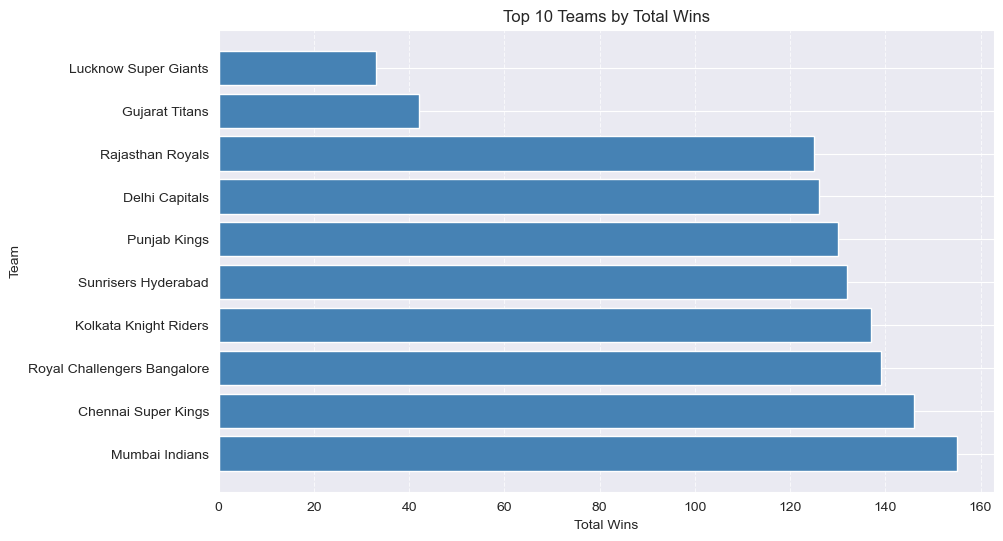

In [18]:
teams = pd.read_csv('teams_data.csv')

wins = matches['match_winner'].value_counts().head(10).reset_index()
wins.columns = ['team_id', 'total_wins']

wins = wins.merge(teams, on='team_id')

plt.figure(figsize=(10,6))
plt.barh(wins['team_name'], wins['total_wins'], color="steelblue")
plt.xlabel("Total Wins")
plt.ylabel("Team")
plt.title("Top 10 Teams by Total Wins")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
#.merge(teams, on='team_id') — ye do tables ko jodta hai ek common column (team_id) ke through. Jaise Excel ka VLOOKUP — 
# wins table mein sirf team ID hai, teams table mein ID + naam hai — merge karne se wins table mein bhi naam aa jata hai.

# Analogy: Soch tere paas ek list hai "Roll number 5 ne 90 marks liye" — 
# aur ek doosri list hai "Roll number 5 = Rahul" — merge karne se milega "Rahul ne 90 marks liye" — ID se naam connect ho gaya.